In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# File paths
TRAIN_PATH = "/Users/nepulseneviratne/Downloads/dataset-1.csv"
TARGET_COLUMN = "Churn"
EVALUATION_SPLIT_PATH = "./evaluation_split.csv"  # organizers only — do not rely on this file existing locally

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


def evaluate_predictions(y_true, y_pred, y_proba):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }
    print("--- Metrics ---")
    for name, value in metrics.items():
        print(f"{name:>10}: {value:.4f}")
    return metrics

## 1. Load the Data

Load the dataset from `TRAIN_PATH` into a dataframe.

In [ ]:
df = pd.read_csv(TRAIN_PATH) # use pandada library
print("Shape:", df.shape)
df.head()

Shape: (5634, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,False
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,False
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,False
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,False
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,False


## 2. Explore and Clean the Dataset


### 2.1 Structure, data types and missing values

In [6]:
df.info()

# Nulls alone are not enough: blank / whitespace-only strings are hidden missing values
string_cols = df.select_dtypes(include=["object", "string"]).columns
blank_counts = df[string_cols].apply(lambda s: s.astype(str).str.strip().eq("").sum())

pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_null": df.isna().sum(),
    "n_blank_string": blank_counts.reindex(df.columns).fillna(0).astype(int),
    "n_unique": df.nunique(),
})

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  Paymen

,dtype,n_null,n_blank_string,n_unique
customerID,str,0,0,5634
gender,str,0,0,2
SeniorCitizen,int64,0,0,2
Partner,str,0,0,2
Dependents,str,0,0,2
tenure,int64,0,0,73
PhoneService,str,0,0,2
MultipleLines,str,0,0,3
InternetService,str,0,0,3
OnlineSecurity,str,0,0,3


### 2.2 Investigate the blank `TotalCharges` rows

In [ ]:
total_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Non-numeric TotalCharges:", total_numeric.isna().sum())
print("Customers with tenure == 0:", (df["tenure"] == 0).sum())
display(df.loc[total_numeric.isna(), ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

# Sanity check: TotalCharges should be roughly tenure * MonthlyCharges
ratio = total_numeric / (df["tenure"] * df["MonthlyCharges"])
print("TotalCharges / (tenure*MonthlyCharges) quantiles:")
print(ratio.replace(np.inf, np.nan).describe().round(3))

Non-numeric TotalCharges: 8
Customers with tenure == 0: 8


,tenure,MonthlyCharges,TotalCharges,Churn
819,0,73.35,,False
1999,0,20.00,,False
2100,0,25.35,,False
4710,0,52.55,,False
5057,0,25.75,,False
5294,0,56.05,,False
5361,0,61.90,,False
5608,0,19.85,,False


TotalCharges / (tenure*MonthlyCharges) quantiles:
count    5626.000
mean        1.001
std         0.051
min         0.689
25%         0.980
50%         1.000
75%         1.019
max         1.531
dtype: float64


In [8]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated customerID:", df["customerID"].duplicated().sum())
dup_mask = df.drop(columns="customerID").duplicated(keep=False)
print("Rows identical apart from customerID:", dup_mask.sum())
display(df.loc[dup_mask].drop(columns="customerID").sort_values(["tenure", "MonthlyCharges"]).head(6))

categorical_cols = [c for c in string_cols if c not in ("customerID", "TotalCharges")]
for col in categorical_cols:
    print(f"{col:<18}", df[col].value_counts().to_dict())

Fully duplicated rows: 0
Duplicated customerID: 0
Rows identical apart from customerID: 29


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
98,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,False
5539,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,False
1029,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,False
2619,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,False
1913,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,False
3122,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,False


gender             {'Male': 2833, 'Female': 2801}
Partner            {'No': 2905, 'Yes': 2729}
Dependents         {'No': 3955, 'Yes': 1679}
PhoneService       {'Yes': 5075, 'No': 559}
MultipleLines      {'No': 2685, 'Yes': 2390, 'No phone service': 559}
InternetService    {'Fiber optic': 2483, 'DSL': 1937, 'No': 1214}
OnlineSecurity     {'No': 2797, 'Yes': 1623, 'No internet service': 1214}
OnlineBackup       {'No': 2442, 'Yes': 1978, 'No internet service': 1214}
DeviceProtection   {'No': 2472, 'Yes': 1948, 'No internet service': 1214}
TechSupport        {'No': 2771, 'Yes': 1649, 'No internet service': 1214}
StreamingTV        {'No': 2226, 'Yes': 2194, 'No internet service': 1214}
StreamingMovies    {'No': 2217, 'Yes': 2203, 'No internet service': 1214}
Contract           {'Month-to-month': 3102, 'Two year': 1359, 'One year': 1173}
PaperlessBilling   {'Yes': 3331, 'No': 2303}
PaymentMethod      {'Electronic check': 1891, 'Mailed check': 1286, 'Bank transfer (automatic)': 1244, 'Credit 

Churn distribution:
Churn
False    0.735
True     0.265
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max,iqr_outliers
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.000,55.000,72.00,0
MonthlyCharges,5634.0,64.929961,30.138105,18.4,35.6625,70.500,90.000,118.75,0
TotalCharges,5634.0,2299.334682,2279.204278,0.0,402.9750,1394.925,3835.825,8684.80,0


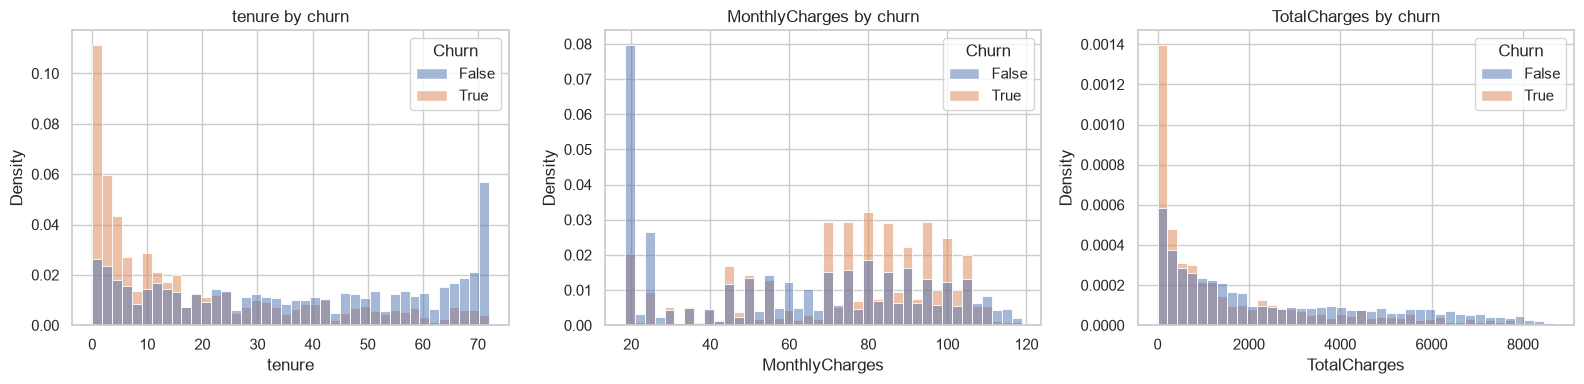

Correlation between numeric columns:


,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.26,0.83
MonthlyCharges,0.26,1.00,0.65
TotalCharges,0.83,0.65,1.00


In [9]:
print("Churn distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).round(3))

eda = df.assign(TotalCharges=total_numeric.fillna(0))
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

q1, q3 = eda[num_cols].quantile(0.25), eda[num_cols].quantile(0.75)
iqr = q3 - q1
outliers = ((eda[num_cols] < q1 - 1.5 * iqr) | (eda[num_cols] > q3 + 1.5 * iqr)).sum()
display(pd.concat([eda[num_cols].describe().T, outliers.rename("iqr_outliers")], axis=1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=eda, x=col, hue=TARGET_COLUMN, bins=40, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

print("Correlation between numeric columns:")
eda[num_cols].corr().round(2)

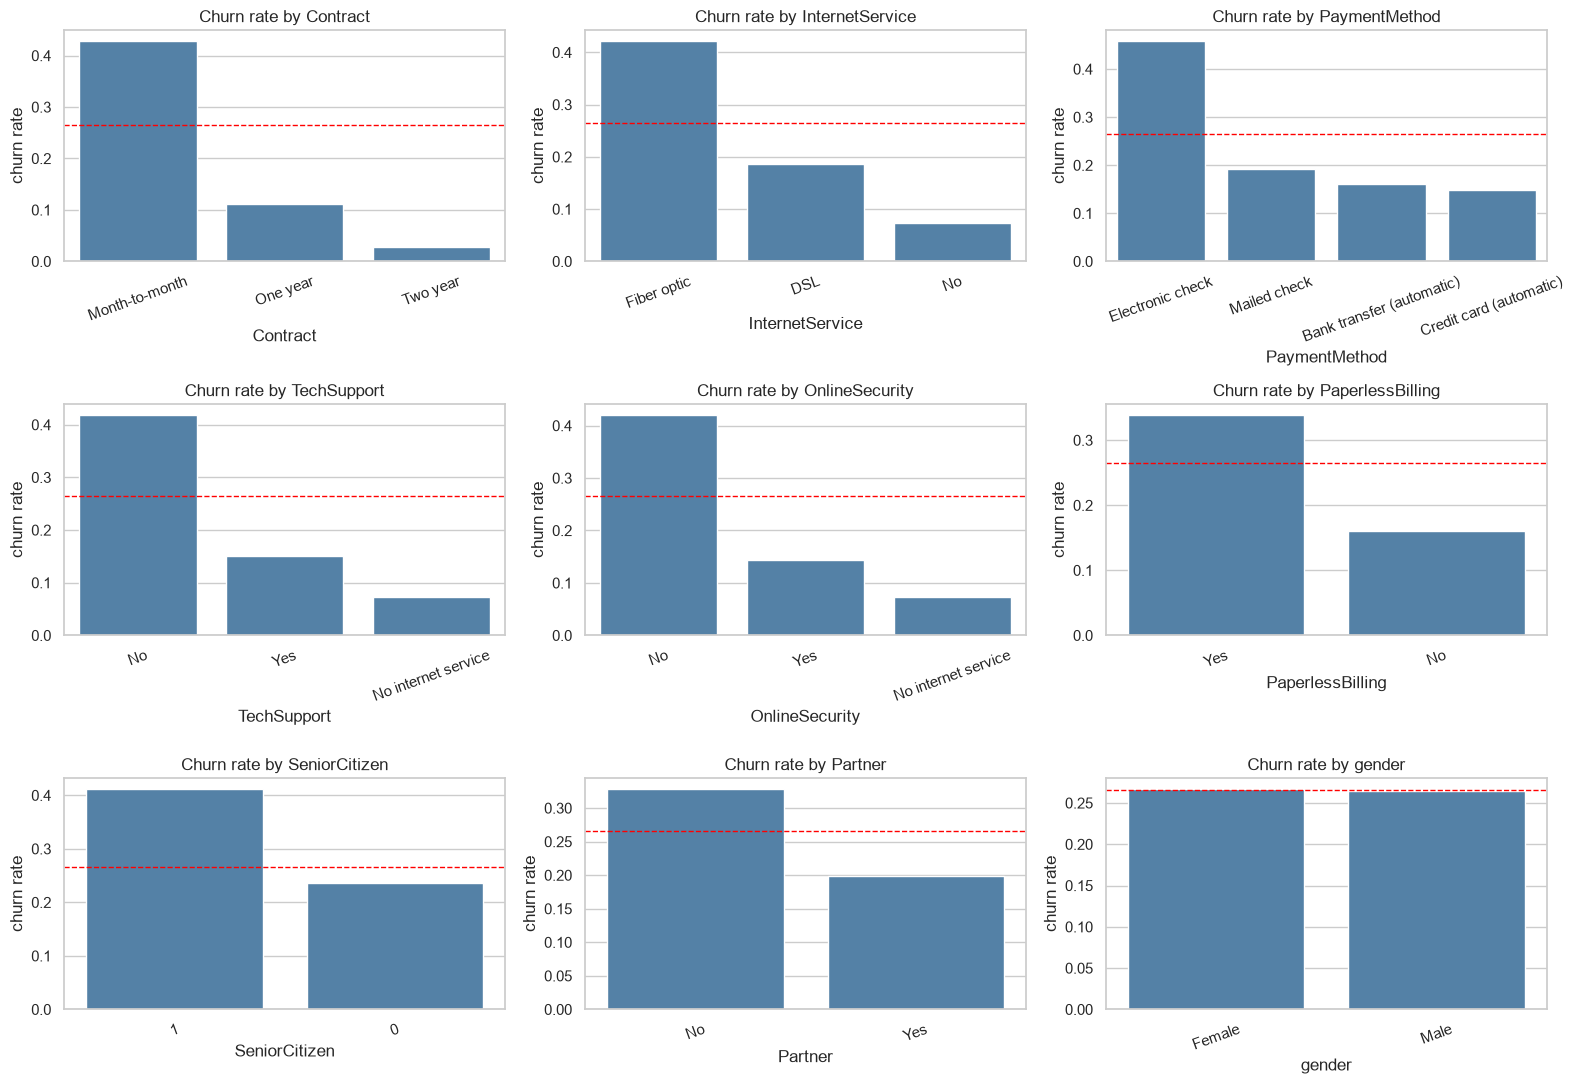

In [10]:
plot_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
             "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Partner", "gender"]
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.ravel(), plot_cols):
    rate = df.groupby(col)[TARGET_COLUMN].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="steelblue")
    ax.axhline(df[TARGET_COLUMN].mean(), ls="--", color="red", lw=1)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("churn rate")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [11]:
NUMERIC_RAW_COLS = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
ADDON_COLS = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]


def data_cleaning(df):
    df = df.copy()
    df = df.drop(columns=["customerID"], errors="ignore")

    text_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in text_cols:
        df[col] = df[col].str.strip().replace("", np.nan)

    for col in NUMERIC_RAW_COLS:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Blank TotalCharges only occur for tenure == 0 (not yet billed)
    df["TotalCharges"] = df["TotalCharges"].fillna(df["tenure"] * df["MonthlyCharges"])

    for col in ADDON_COLS:
        if col in df:
            df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

    if TARGET_COLUMN in df:
        df[TARGET_COLUMN] = (
            df[TARGET_COLUMN].astype(str).str.strip().str.lower()
            .map({"true": 1, "yes": 1, "1": 1, "false": 0, "no": 0, "0": 0})
        )
    return df


cleaned = data_cleaning(df)
print("Shape after cleaning:", cleaned.shape)
print("Remaining missing values:", int(cleaned.isna().sum().sum()))
print("Target values:", cleaned[TARGET_COLUMN].value_counts().to_dict())
print("OnlineSecurity levels:", cleaned["OnlineSecurity"].unique().tolist())
cleaned.head()

Shape after cleaning: (5634, 20)
Remaining missing values: 0
Target values: {0: 4139, 1: 1495}
OnlineSecurity levels: ['No', 'Yes']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,35,No,No,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,0
1,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,0
2,Male,0,Yes,Yes,13,No,No,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,0
3,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,0
4,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,0


In [ ]:
SERVICE_COLS = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
                "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
PROTECTION_COLS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]


def feature_engineering(df):
    df = df.copy()

    df["AvgMonthlyCharge"] = np.where(df["tenure"] > 0,
                                      df["TotalCharges"] / df["tenure"].where(df["tenure"] > 0),
                                      df["MonthlyCharges"])
    df["ChargeDelta"] = df["MonthlyCharges"] - df["AvgMonthlyCharge"]

    df["NumServices"] = (df[SERVICE_COLS] == "Yes").sum(axis=1) + (df["InternetService"] != "No").astype(int)
    df["NumProtectionServices"] = (df[PROTECTION_COLS] == "Yes").sum(axis=1)

    df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
                               labels=["0-12", "13-24", "25-48", "49-60", "61+"]).astype(str)

    df["AutoPayment"] = df["PaymentMethod"].str.contains("automatic", case=False, na=False).astype(int)
    df["MonthToMonthEcheck"] = ((df["Contract"] == "Month-to-month")
                                & (df["PaymentMethod"] == "Electronic check")).astype(int)
    df["FiberNoSupport"] = ((df["InternetService"] == "Fiber optic")
                            & (df["TechSupport"] != "Yes")).astype(int)
    return df


engineered = feature_engineering(cleaned)
new_cols = ["AvgMonthlyCharge", "ChargeDelta", "NumServices", "NumProtectionServices",
            "TenureGroup", "AutoPayment", "MonthToMonthEcheck", "FiberNoSupport"]

print("Churn rate by engineered feature:")
for col in ["TenureGroup", "NumProtectionServices", "AutoPayment", "MonthToMonthEcheck", "FiberNoSupport"]:
    print(f"\n{col}:", engineered.groupby(col)[TARGET_COLUMN].mean().round(3).to_dict())

print("\nCorrelation of numeric engineered features with churn:")
print(engineered[["AvgMonthlyCharge", "ChargeDelta", "NumServices"]].corrwith(engineered[TARGET_COLUMN]).round(3))

Churn rate by engineered feature:

TenureGroup: {'0-12': 0.473, '13-24': 0.286, '25-48': 0.202, '49-60': 0.153, '61+': 0.068}

NumProtectionServices: {0: 0.296, 1: 0.392, 2: 0.242, 3: 0.12, 4: 0.055}

AutoPayment: {0: 0.35, 1: 0.155}

MonthToMonthEcheck: {0: 0.166, 1: 0.542}

FiberNoSupport: {0: 0.16, 1: 0.493}

Correlation of numeric engineered features with churn:
AvgMonthlyCharge    0.197
ChargeDelta         0.002
NumServices        -0.015
dtype: float64


In [ ]:
NUMERIC_FEATURES = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges",
                    "AvgMonthlyCharge", "ChargeDelta", "NumServices", "NumProtectionServices",
                    "AutoPayment", "MonthToMonthEcheck", "FiberNoSupport"]
CATEGORICAL_FEATURES = ["gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
                        "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                        "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
                        "PaperlessBilling", "PaymentMethod", "TenureGroup"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def build_preprocessor():
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric, NUMERIC_FEATURES),
        ("cat", categorical, CATEGORICAL_FEATURES),
    ], verbose_feature_names_out=False)


preprocessor = None  

def fit_preprocessor(raw_train_df):
    global preprocessor
    train_features = feature_engineering(data_cleaning(raw_train_df))
    preprocessor = build_preprocessor().fit(train_features[FEATURES])
    return preprocessor


def scale_features(df):
    if preprocessor is None:
        raise RuntimeError("Call fit_preprocessor() on the training split first.")
    transformed = preprocessor.transform(df[FEATURES])
    out = pd.DataFrame(transformed, columns=preprocessor.get_feature_names_out(), index=df.index)
    if TARGET_COLUMN in df:
        out[TARGET_COLUMN] = df[TARGET_COLUMN].values
    return out

In [14]:
# Do not modify this function
def preprocess_data(df):
    df = df.copy()
    df = data_cleaning(df)
    df = feature_engineering(df)
    df = scale_features(df)

    return df

## 5. Train / Validation / Test Split


In [15]:
def split_data(df, val_size=0.15, test_size=0.15):
    train_val_split, test_split = train_test_split(
        df, test_size=test_size, stratify=df[TARGET_COLUMN], random_state=RANDOM_STATE)
    train_split, validation_split = train_test_split(
        train_val_split, test_size=val_size / (1 - test_size),
        stratify=train_val_split[TARGET_COLUMN], random_state=RANDOM_STATE)
    return train_split, validation_split, test_split


raw_train, raw_val, raw_test = split_data(df)
fit_preprocessor(raw_train)

train_split = preprocess_data(raw_train)
validation_split = preprocess_data(raw_val)
test_split = preprocess_data(raw_test)

X_train, y_train = train_split.drop(columns=[TARGET_COLUMN]), train_split[TARGET_COLUMN]
X_val, y_val = validation_split.drop(columns=[TARGET_COLUMN]), validation_split[TARGET_COLUMN]
X_test, y_test = test_split.drop(columns=[TARGET_COLUMN]), test_split[TARGET_COLUMN]

summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "churn_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "validation", "test"]).round(3)
display(summary)
print("Number of model features:", X_train.shape[1])
X_train.head()

,rows,churn_rate
train,3943,0.266
validation,845,0.265
test,846,0.265


Number of model features: 38


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlyCharge,ChargeDelta,NumServices,NumProtectionServices,AutoPayment,MonthToMonthEcheck,...,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_0-12,TenureGroup_13-24,TenureGroup_25-48,TenureGroup_49-60,TenureGroup_61+
2285,-0.439364,0.032559,-0.118094,-0.117230,-0.113686,-0.047173,0.365886,1.340653,-0.863402,-0.592679,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
5146,-0.439364,-0.412502,1.193412,0.056197,1.492461,-3.544805,0.796410,-0.212740,-0.863402,1.687255,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3986,-0.439364,1.124981,1.676948,1.950567,1.585720,1.004868,2.087984,2.117349,1.158209,-0.592679,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2853,2.276016,-0.372042,0.357161,-0.280755,0.226183,1.519582,-0.495163,-0.212740,1.158209,-0.592679,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3521,-0.439364,-1.221704,-1.497495,-0.975662,-1.297644,-2.282917,-1.356212,-0.989436,-0.863402,-0.592679,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


## 6. Model Training, and Hyperparameter Tuning


In [16]:
search_space = {
    "LogisticRegression": (
        lambda **p: LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **p),
        {"C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0], "class_weight": [None, "balanced"]},
    ),
    "RandomForest": (
        lambda **p: RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE, **p),
        {"max_depth": [6, 10, None], "min_samples_leaf": [5, 10, 20],
         "max_features": ["sqrt", 0.3], "class_weight": [None, "balanced"]},
    ),
    "HistGradientBoosting": (
        lambda **p: HistGradientBoostingClassifier(random_state=RANDOM_STATE, **p),
        {"learning_rate": [0.03, 0.05, 0.1], "max_depth": [3, 5], "max_iter": [100, 200, 400],
         "min_samples_leaf": [20, 50], "l2_regularization": [0.0, 1.0]},
    ),
}

results = []
for name, (make_model, grid) in search_space.items():
    for params in ParameterGrid(grid):
        clf = make_model(**params).fit(X_train, y_train)
        results.append({
            "model": name,
            "params": params,
            "train_auc": roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]),
            "val_auc": roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1]),
        })

results_df = pd.DataFrame(results).sort_values("val_auc", ascending=False)
best_per_family = results_df.groupby("model", sort=False).head(1).reset_index(drop=True)
pd.set_option("display.max_colwidth", 200)
best_per_family.round(4)

,model,params,train_auc,val_auc
0,RandomForest,"{'class_weight': None, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 20}",0.8818,0.8594
1,HistGradientBoosting,"{'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_depth': 3, 'max_iter': 100, 'min_samples_leaf': 20}",0.8609,0.8572
2,LogisticRegression,"{'C': 0.03, 'class_weight': None}",0.8471,0.8565



### 6.2 Train vs. validation metrics for each candidate (threshold 0.5)

In [18]:
candidates = {
    row.model: search_space[row.model][0](**row.params).fit(X_train, y_train)
    for row in best_per_family.itertuples()
}
candidates["SoftVotingEnsemble"] = VotingClassifier(
    estimators=[(name, est) for name, est in candidates.items()], voting="soft"
).fit(X_train, y_train)

comparison = []
for name, clf in candidates.items():
    print(f"\n========== {name} ==========")
    print("[train]")
    train_m = evaluate_predictions(y_train, clf.predict(X_train), clf.predict_proba(X_train)[:, 1])
    print("[validation]")
    val_m = evaluate_predictions(y_val, clf.predict(X_val), clf.predict_proba(X_val)[:, 1])
    comparison.append({"model": name, **{f"train_{k}": v for k, v in train_m.items()},
                       **{f"val_{k}": v for k, v in val_m.items()}})

comparison_df = pd.DataFrame(comparison).set_index("model").sort_values("val_roc_auc", ascending=False)
comparison_df.round(4)


========== RandomForest ==========
[train]
--- Metrics ---
  accuracy: 0.8202
 precision: 0.7230
    recall: 0.5234
  f1_score: 0.6072
   roc_auc: 0.8818
[validation]
--- Metrics ---
  accuracy: 0.8095
 precision: 0.6981
    recall: 0.4955
  f1_score: 0.5796
   roc_auc: 0.8594

========== HistGradientBoosting ==========
[train]
--- Metrics ---
  accuracy: 0.8040
 precision: 0.7095
    recall: 0.4432
  f1_score: 0.5456
   roc_auc: 0.8609
[validation]
--- Metrics ---
  accuracy: 0.8178
 precision: 0.7536
    recall: 0.4643
  f1_score: 0.5746
   roc_auc: 0.8572

========== LogisticRegression ==========
[train]
--- Metrics ---
  accuracy: 0.8022
 precision: 0.6675
    recall: 0.5081
  f1_score: 0.5770
   roc_auc: 0.8471
[validation]
--- Metrics ---
  accuracy: 0.8095
 precision: 0.6821
    recall: 0.5268
  f1_score: 0.5945
   roc_auc: 0.8565

========== SoftVotingEnsemble ==========
[train]
--- Metrics ---
  accuracy: 0.8106
 precision: 0.7055
    recall: 0.4919
  f1_score: 0.5796
   roc_

,train_accuracy,train_precision,train_recall,train_f1_score,train_roc_auc,val_accuracy,val_precision,val_recall,val_f1_score,val_roc_auc
model,,,,,,,,,,
SoftVotingEnsemble,0.8106,0.7055,0.4919,0.5796,0.8666,0.8201,0.7222,0.5223,0.6062,0.8607
RandomForest,0.8202,0.7230,0.5234,0.6072,0.8818,0.8095,0.6981,0.4955,0.5796,0.8594
HistGradientBoosting,0.8040,0.7095,0.4432,0.5456,0.8609,0.8178,0.7536,0.4643,0.5746,0.8572
LogisticRegression,0.8022,0.6675,0.5081,0.5770,0.8471,0.8095,0.6821,0.5268,0.5945,0.8565




### 6.3 Decision-threshold tuning (on validation)

Selected model: SoftVotingEnsemble
Max F1 threshold: 0.30  |  chosen threshold: 0.36


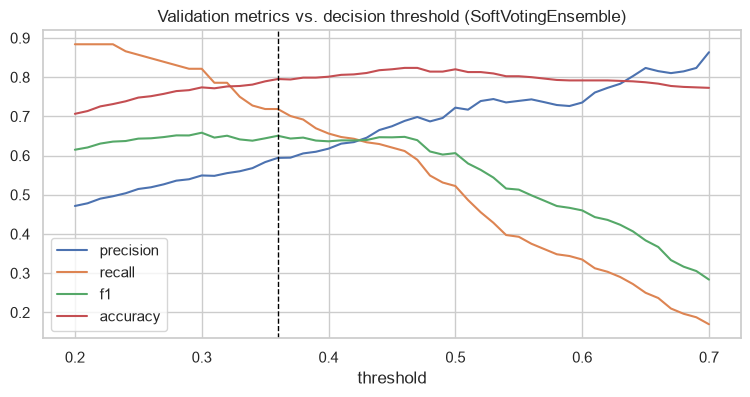

[validation @ 0.5]
--- Metrics ---
  accuracy: 0.8201
 precision: 0.7222
    recall: 0.5223
  f1_score: 0.6062
   roc_auc: 0.8607
[validation @ 0.36]
--- Metrics ---
  accuracy: 0.7953
 precision: 0.5941
    recall: 0.7188
  f1_score: 0.6505
   roc_auc: 0.8607


In [20]:
best_model_name = comparison_df.index[0]
model = candidates[best_model_name]
print("Selected model:", best_model_name)

val_proba = model.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.20, 0.71, 0.01)
threshold_scores = pd.DataFrame({
    "threshold": thresholds,
    "precision": [precision_score(y_val, val_proba >= t, zero_division=0) for t in thresholds],
    "recall": [recall_score(y_val, val_proba >= t) for t in thresholds],
    "f1": [f1_score(y_val, val_proba >= t) for t in thresholds],
    "accuracy": [accuracy_score(y_val, val_proba >= t) for t in thresholds],
})

# F1 is flat over a wide range, so take the near-optimal-F1 threshold with the best accuracy
near_best = threshold_scores[threshold_scores["f1"] >= threshold_scores["f1"].max() - 0.01]
best_threshold = float(near_best.loc[near_best["accuracy"].idxmax(), "threshold"].round(2))
print(f"Max F1 threshold: {threshold_scores.loc[threshold_scores['f1'].idxmax(), 'threshold']:.2f}"
      f"  |  chosen threshold: {best_threshold}")

threshold_scores.set_index("threshold")[["precision", "recall", "f1", "accuracy"]].plot(figsize=(9, 4))
plt.axvline(best_threshold, color="black", ls="--", lw=1)
plt.title(f"Validation metrics vs. decision threshold ({best_model_name})")
plt.show()

print("[validation @ 0.5]")
_ = evaluate_predictions(y_val, (val_proba >= 0.5).astype(int), val_proba)
print(f"[validation @ {best_threshold}]")
_ = evaluate_predictions(y_val, (val_proba >= best_threshold).astype(int), val_proba)


### 6.4 Final prediction function
`predict_churn(df)`

In [21]:
def predict_churn(df):
    processed = preprocess_data(df)
    features = processed.drop(columns=[TARGET_COLUMN], errors="ignore")
    probabilities = model.predict_proba(features)[:, 1]
    predictions = (probabilities >= best_threshold).astype(int)
    return predictions, probabilities

## 7. I Evaluate on the Held-Out Test Set

[TEST] SoftVotingEnsemble @ threshold 0.36
--- Metrics ---
  accuracy: 0.7849
 precision: 0.5745
    recall: 0.7232
  f1_score: 0.6403
   roc_auc: 0.8446

Classification report:
              precision    recall  f1-score   support

    No churn       0.89      0.81      0.85       622
       Churn       0.57      0.72      0.64       224

    accuracy                           0.78       846
   macro avg       0.73      0.77      0.74       846
weighted avg       0.81      0.78      0.79       846



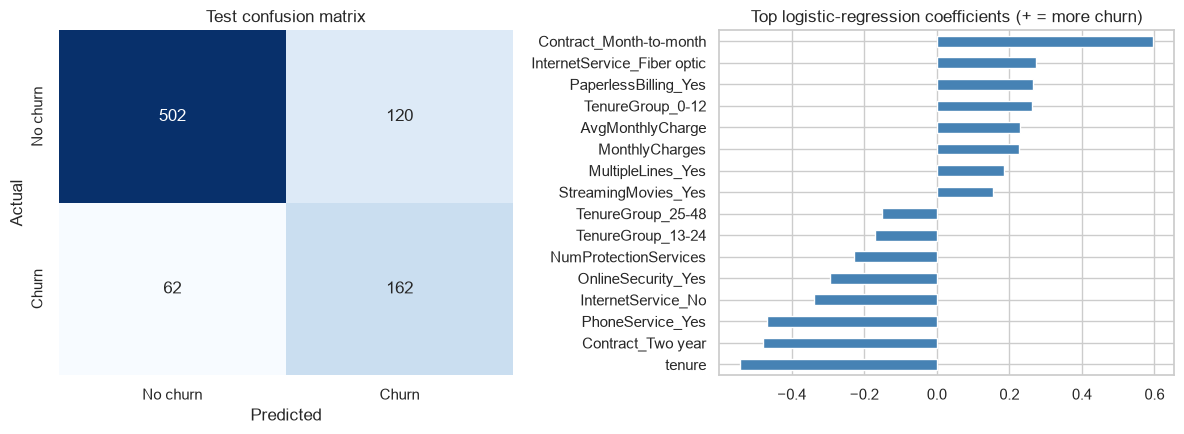

,accuracy,precision,recall,f1_score,roc_auc
test,0.7849,0.5745,0.7232,0.6403,0.8446


In [22]:
X_test_raw = raw_test.drop(columns=[TARGET_COLUMN])
y_test_raw = raw_test[TARGET_COLUMN]

test_pred, test_proba = predict_churn(X_test_raw)
print(f"[TEST] {best_model_name} @ threshold {best_threshold}")
test_metrics = evaluate_predictions(y_test_raw, test_pred, test_proba)

print("\nClassification report:")
print(classification_report(y_test_raw.astype(int), test_pred, target_names=["No churn", "Churn"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cm = confusion_matrix(y_test_raw.astype(int), test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Test confusion matrix")

lr = candidates["LogisticRegression"]
coefs = pd.Series(lr.coef_[0], index=X_train.columns).sort_values()
pd.concat([coefs.head(8), coefs.tail(8)]).plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Top logistic-regression coefficients (+ = more churn)")
plt.tight_layout()
plt.show()

pd.DataFrame([test_metrics], index=["test"]).round(4)